# Variant Analysis Notebook

This notebook goes through the variant analysis process starting from raw FASTQ files and ending with annotated VCF files and analysis.

Note that I am only showing the code for hte SRR13973983 sample (the baseline cfDNA). The same code was also run for the SRR13973984 and SRR13973895 samples as well. 

## Getting the Raw Data

Here, I use SRA command line function `fastq-dump` to grab the raw data from NCBI's SRA. 

In [11]:
%%bash
mkdir SRR13973983_fastqs
fastq-dump --split-3 --skip-technical --clip --read-filter pass --outdir ./SRR13973983_fastqs ./SRR13973983

mkdir: cannot create directory ‘SRR13973983_fastqs’: File exists


Rejected 43282 READS because of filtering out non-biological READS
Read 4429671 spots for ./SRR13973983
Written 4429671 spots for ./SRR13973983


For this command:  
    --split-3: separates the paired reads into their left and right ends. Any unmatched reads go into a separate file.  
    --skip-technical: Returns only biological reads. Technical reads are rejected.  
    --clip: Trims any SRA tags present in the reads   
    --read-filer pass: only returns reads that pass filtering  
    --outdir: specifies the output directory  

The output directory will contain 3 files: the two paired end files (\*_1.fastq and \*_2.fastq) and the singleton file (\*.fastq). For the purposes of this exercise, I will only be looking at the paired reads.

## Preprocessing

Once we have the raw FASTQ files, it is always a good idea to run FASTQC on the data for quality control. 

In [ ]:
%%bash
mkdir SRR13973983_fastqc
fastqc -o ./SRR13973983_fastqc ./SRR13973983_fastqs/*.fastq

## Alignment with BWA-MEM2

Now we move to aligning the paired reads to the hg19 reference genome. Here I will be aligning it to chromosome 17 to look for variants in one of the most commonly mutated genes in the this study, TP53. 

I am assuming that the `ref_genomes` directory contains the pre-indexed chromosome 17. 

In [ ]:
%%bash
mkdir SRR13973983_analysis
bwa-mem2 mem ./ref_genomes/chr17.fa ./SRR13973983_fastqs/SRR13973983_pass_1.fastq SRR13973983_fastqs/SRR13973983_pass_2.fastq | samtools view -T ./ref_genomes/chr17.fa -bo SRR13973983_analysis/SRR13973983_pass_chr17.bam - 

In [ ]:
%%bash
# sorting and indexing
samtools sort -o SRR13973983_analysis/SRR13973983_pass_chr17_sort.bam SRR13973983_analysis/SRR13973983_pass_chr17.bam
samtools index SRR13973983_analysis/SRR13973983_pass_chr17_sort.bam

[bam_sort_core] merging from 3 files and 1 in-memory blocks...
[bam_sort_core] merging from 3 files and 1 in-memory blocks...


## Variant Calling with VarScan2

Now we use VarScan2 to call SNPs from our sorted .bam file. Since some of these variants might be in very low frequency, I am changing the option `--min-var-freq` to 0.01.

In [ ]:
%%bash
# generating mpileup files and using VarScan2 to create .vcf files
samtools mpileup -f ./ref_genomes/chr17.fa SRR13973983_analysis/SRR13973983_pass_chr17_sort.bam | java -jar VarScan.v2.3.9.jar mpileup2snp --min-var-freq 0.01 > SRR13973983_analysis/SRR13973983_pass_chr17.vcf

[mpileup] 1 samples in 1 input files
Only SNPs will be reported
Min coverage:	8
Min reads2:	2
Min var freq:	0.01
Min avg qual:	15
P-value thresh:	0.01


ERROR! Session/line number was not unique in database. History logging moved to new session 15


Reading input from STDIN
25998932 bases in pileup file
94145 variant positions (91234 SNP, 2911 indel)
2697 were failed by the strand-filter
88652 variant positions reported (88652 SNP, 0 indel)
[mpileup] 1 samples in 1 input files
Only SNPs will be reported
Min coverage:	8
Min reads2:	2
Min var freq:	0.01
Min avg qual:	15
P-value thresh:	0.01
Reading input from STDIN
19127383 bases in pileup file
104821 variant positions (101928 SNP, 2893 indel)
2807 were failed by the strand-filter
99215 variant positions reported (99215 SNP, 0 indel)


## VCF Annotation with SnpEff

Using SnpEff, we can annotate our new .vcf files. This gives us information such as gene names, predicted AA changes, and functional effect predictions.

In [ ]:
%%bash
snpEff hg19 SRR13973983_analysis/SRR13973983_pass_chr17.vcf > SRR13973983_analysis/SRR13973983_pass_chr17_anno.vcf

In [ ]:
%%bash
# adding ClinVar annotations with SnpSift; currently adding ClinVar header information, but nothing else. Working on fixing this
SnpSift annotate clinvar.vcf.gz SRR13973983_analysis/SRR13973983_pass_chr17_anno.vcf > SRR13973983_analysis/SRR13973983_pass_chr17_anno_ClinVar.vcf

## TP53 Analysis

First I am going to take a look at the total number of variants present on chromosome 17 and the total number of TP53 variants for all 3 samples:

(Note that I have ordered SRR13973985 before SRR13973984; this is the intended order of the samples chronologically by collection date)

In [ ]:
%%bash
# Total variants; grep command simply removes the header sequence
cat SRR13973983_analysis/SRR13973983_pass_chr17_anno_ClinVar.vcf | grep -Ev '^#|Chrom' | wc -l
cat SRR13973985_analysis/SRR13973985_pass_chr17_anno_ClinVar.vcf | grep -Ev '^#|Chrom' | wc -l
cat SRR13973984_analysis/SRR13973984_pass_chr17_anno_ClinVar.vcf | grep -Ev '^#|Chrom' | wc -l

# Total TP53 variants; awk command selects only the lines where TP53 is the mutated gene
cat SRR13973983_analysis/SRR13973983_pass_chr17_anno_ClinVar.vcf | grep -Ev '^#|Chrom' | awk '{split($8, x, "|"); if (x[4] == "TP53") {print}}' | wc -l
cat SRR13973985_analysis/SRR13973985_pass_chr17_anno_ClinVar.vcf | grep -Ev '^#|Chrom' | awk '{split($8, x, "|"); if (x[4] == "TP53") {print}}' | wc -l
cat SRR13973984_analysis/SRR13973984_pass_chr17_anno_ClinVar.vcf | grep -Ev '^#|Chrom' | awk '{split($8, x, "|"); if (x[4] == "TP53") {print}}' | wc -l

99215
56268
41156
59
27
18


For TP53 variants and total chromosome 17 variants, we see a decrease in the number of variants across the 3 time points. These results could potentially be caused by the ongoing treatment, but we cannot conclusively determine that with this data alone. 

Focusing just on the TP53 mutations now, let's look at the distribution of mutation types for each of the time points: 

In [23]:
%%bash
# now just printing the mutation type and counting them. 
cat SRR13973983_analysis/SRR13973983_pass_chr17_anno_ClinVar.vcf | awk '{split($8, x, "|"); if (x[4] == "TP53") {print x[2]}}' | sort | uniq -c | sort -n > SRR13973983_analysis/count.txt
cat SRR13973985_analysis/SRR13973985_pass_chr17_anno_ClinVar.vcf | awk '{split($8, x, "|"); if (x[4] == "TP53") {print x[2]}}' | sort | uniq -c | sort -n > SRR13973985_analysis/count.txt
cat SRR13973984_analysis/SRR13973984_pass_chr17_anno_ClinVar.vcf | awk '{split($8, x, "|"); if (x[4] == "TP53") {print x[2]}}' | sort | uniq -c | sort -n > SRR13973984_analysis/count.txt

/tmp/ipykernel_48630/2095661481.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_SRR13973983 = pd.read_csv("SRR13973983_analysis/count.txt", delim_whitespace=True, header=None)


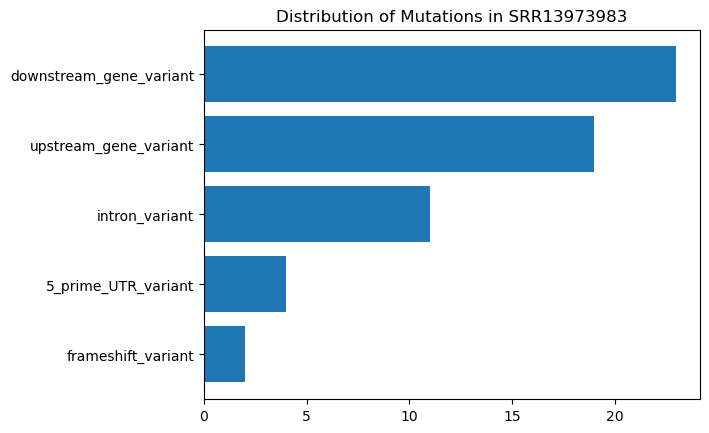

/tmp/ipykernel_48630/2095661481.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_SRR13973985 = pd.read_csv("SRR13973985_analysis/count.txt", delim_whitespace=True, header=None)


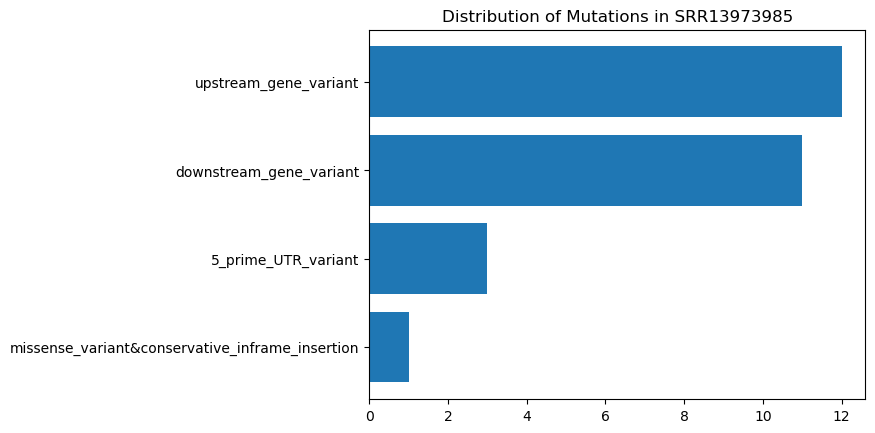

/tmp/ipykernel_48630/2095661481.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_SRR13973984 = pd.read_csv("SRR13973984_analysis/count.txt", delim_whitespace=True, header=None)


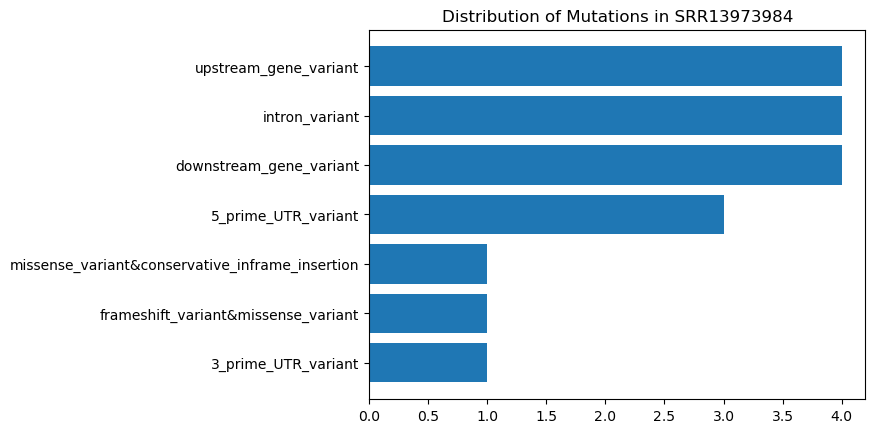

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# SRR13973983
df_SRR13973983 = pd.read_csv("SRR13973983_analysis/count.txt", delim_whitespace=True, header=None)
counts = df_SRR13973983.iloc[:,0]
types = df_SRR13973983.iloc[:,1]

plt.barh(types, counts)
plt.title('Distribution of Mutations in SRR13973983')
plt.show()

# SRR13973985
df_SRR13973985 = pd.read_csv("SRR13973985_analysis/count.txt", delim_whitespace=True, header=None)
counts = df_SRR13973985.iloc[:,0]
types = df_SRR13973985.iloc[:,1]

plt.barh(types, counts)
plt.title('Distribution of Mutations in SRR13973985')
plt.show()

# SRR13973984
df_SRR13973984 = pd.read_csv("SRR13973984_analysis/count.txt", delim_whitespace=True, header=None)
counts = df_SRR13973984.iloc[:,0]
types = df_SRR13973984.iloc[:,1]

plt.barh(types, counts)
plt.title('Distribution of Mutations in SRR13973984')
plt.show()